In [10]:
import pandas as pd
import numpy as np
from pprint import pprint

In [7]:
df = pd.read_csv('food_waste_data.csv')
print("Succesfully loaded the data.")
print(f"Shape: {df.shape}")

Succesfully loaded the data.
Shape: (1782, 11)


In [20]:
print(f"The first 5 rows of the dataset are :\n")
display(df.head())
print("\nDataset Information: \n")
display(df.info())

The first 5 rows of the dataset are :



,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25



Dataset Information: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


None

In [21]:
print("Columns in the dataset: \n")
pprint(list(df.columns))
print("\nChecking for null values in the dataset: \n")
display(df.isnull().sum())

Columns in the dataset: 

['Type of Food',
 'Number of Guests',
 'Event Type',
 'Quantity of Food',
 'Storage Conditions',
 'Purchase History',
 'Seasonality',
 'Preparation Method',
 'Geographical Location',
 'Pricing',
 'Wastage Food Amount']

Checking for null values in the dataset: 



Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

In [22]:
print(df.describe())

print("\nCategorical Columns:")

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    
    print(f"\n{column}")
    print(df[column].value_counts())

       Number of Guests  Quantity of Food  Wastage Food Amount
count       1782.000000       1782.000000          1782.000000
mean         317.804714        411.125701            28.536476
std           67.829658         65.204674            10.461317
min          207.000000        280.000000            10.000000
25%          267.000000        350.000000            20.000000
50%          302.000000        400.000000            26.500000
75%          350.000000        480.000000            35.000000
max          491.000000        500.000000            63.000000

Categorical Columns:

Type of Food
Type of Food
Meat              437
Baked Goods       419
Dairy Products    387
Fruits            328
Vegetables        211
Name: count, dtype: int64

Event Type
Event Type
Corporate           515
Social Gathering    461
Wedding             438
Birthday            368
Name: count, dtype: int64

Storage Conditions
Storage Conditions
Room Temperature    1157
Refrigerated         625
Name: count, d

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

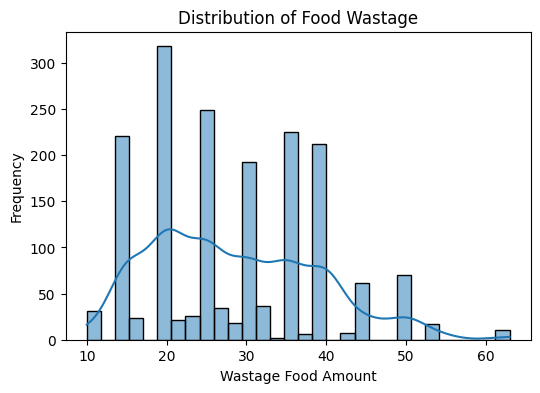

In [27]:
plt.figure(figsize=(6, 4))

sns.histplot(df["Wastage Food Amount"], bins=30, kde=True)

plt.title("Distribution of Food Wastage")
plt.xlabel("Wastage Food Amount")
plt.ylabel("Frequency")

plt.show()

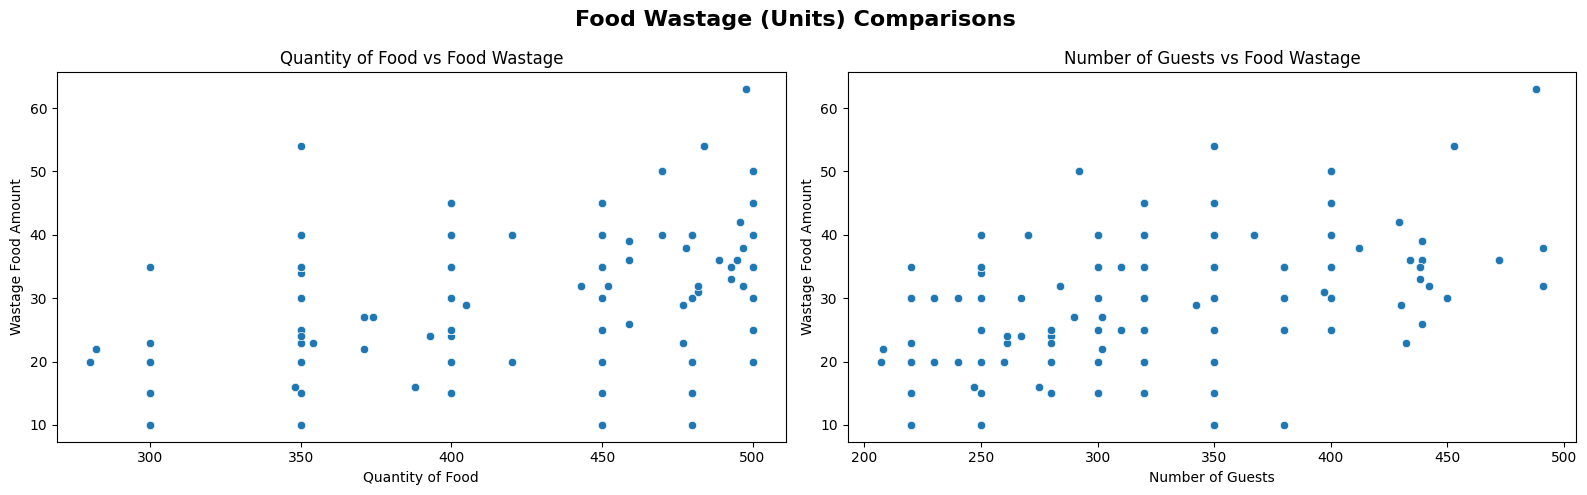

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Food Wastage (Units) Comparisons", fontsize=16, fontweight="bold")

# Quantity of Food vs Food Wastage
sns.scatterplot(
    data=df,
    x="Quantity of Food",
    y="Wastage Food Amount",
    ax=axes[0]
)
axes[0].set_title("Quantity of Food vs Food Wastage")


# Number of Guests vs Food Wastage
sns.scatterplot(
    data=df,
    x="Number of Guests",
    y="Wastage Food Amount",
    ax=axes[1]
)
axes[1].set_title("Number of Guests vs Food Wastage")

plt.tight_layout()
plt.show()

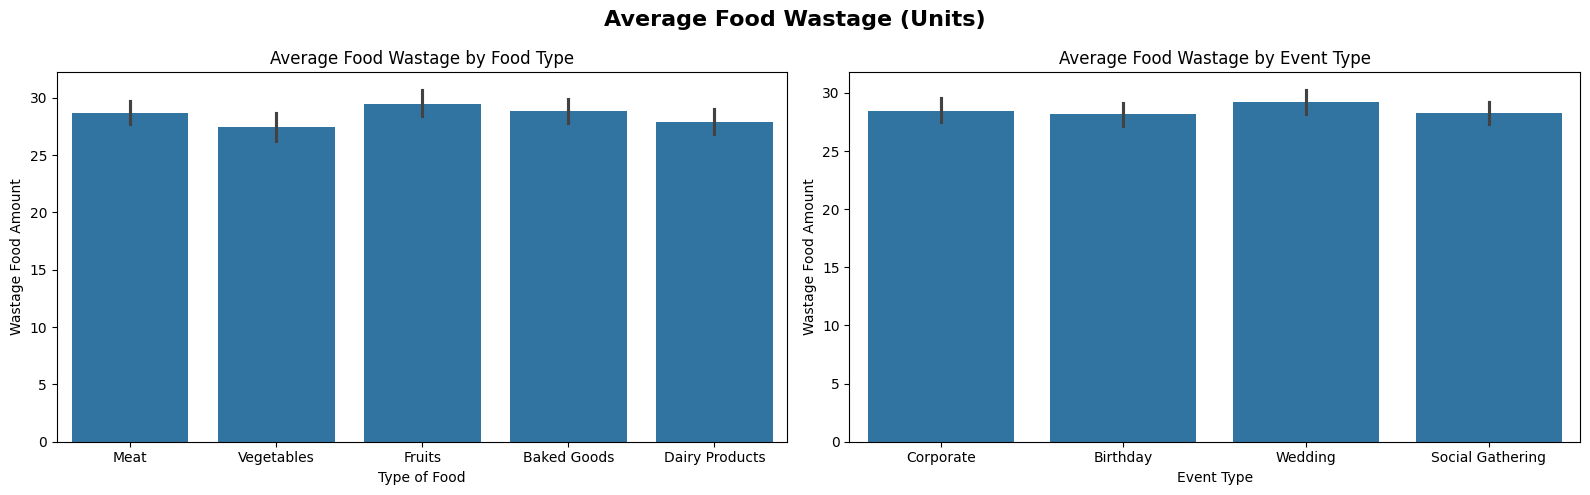

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Average Food Wastage (Units)", fontsize=16, fontweight="bold")

# Average Food Wastage by Food Type
sns.barplot(
    data=df,
    x="Type of Food",
    y="Wastage Food Amount",
    ax=axes[0]
)

axes[0].set_title("Average Food Wastage by Food Type")


# Average Food Wastage by Event Type
sns.barplot(
    data=df,
    x="Event Type",
    y="Wastage Food Amount",
    ax=axes[1]
)
axes[1].set_title("Average Food Wastage by Event Type")

plt.tight_layout()
plt.show()

In [38]:
df["Food_Per_Guest"] = (df["Quantity of Food"] / df["Number of Guests"])

#Checking the distribution of Food_Per_Guest: 
df[["Number of Guests", "Quantity of Food", "Food_Per_Guest", "Wastage Food Amount"]].head()

,Number of Guests,Quantity of Food,Food_Per_Guest,Wastage Food Amount
0,310,450,1.451613,25
1,400,500,1.250000,40
2,302,371,1.228477,27
3,491,497,1.012220,32
4,300,400,1.333333,25
